# Engineering Graduate Salary Prediction - Multivariate Linear Regression

**Mission.** Extending the *Stint* mission (connecting ALU students to real
opportunities), this notebook builds a regression model that predicts an
engineering graduate's **starting salary** from academic records, standardized
aptitude and domain-skill scores, and Big-Five personality traits. The goal is to
surface which factors actually move employability and pay.

**Dataset.** AMEO 2015 *Engineering Graduate Salary Prediction* (Aspiring Minds
Employability Outcomes) - **2,998 rows × 34 columns**, target `Salary` (INR).
Source: Kaggle `manishkc06/engineering-graduate-salary-prediction`.

We (1) explore & visualize the data, (2) engineer features, (3) standardize,
(4) compare **four** regression algorithms - stochastic gradient descent,
closed-form linear regression, a decision tree, and a random forest - (5) plot
train/test loss curves, (6) save the best model, and (7) predict a single row.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
DATA = Path("data/Engineering_graduate_salary.csv")
MODELS = Path("models"); MODELS.mkdir(exist_ok=True)

## 1. Load and inspect the data

In [2]:
df = pd.read_csv(DATA)
print("Shape:", df.shape)
df.head()

Shape: (2998, 34)


,ID,Gender,DOB,10percentage,10board,12graduation,12percentage,12board,CollegeID,CollegeTier,...,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
0,604399,f,1990-10-22,87.80,cbse,2009,84.00,cbse,6920,1,...,-1,-1,-1,-1,-0.1590,0.3789,1.2396,0.14590,0.2889,445000
1,988334,m,1990-05-15,57.00,cbse,2010,64.50,cbse,6624,2,...,-1,-1,-1,-1,1.1336,0.0459,1.2396,0.52620,-0.2859,110000
2,301647,m,1989-08-21,77.33,"maharashtra state board,pune",2007,85.17,amravati divisional board,9084,2,...,-1,-1,260,-1,0.5100,-0.1232,1.5428,-0.29020,-0.2875,255000
3,582313,m,1991-05-04,84.30,cbse,2009,86.00,cbse,8195,1,...,-1,-1,-1,-1,-0.4463,0.2124,0.3174,0.27270,0.4805,420000
4,339001,f,1990-10-30,82.00,cbse,2008,75.00,cbse,4889,2,...,-1,-1,-1,-1,-1.4992,-0.7473,-1.0697,0.06223,0.1864,200000


In [3]:
df.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2998.0,NaN,NaN,NaN,664892.583389,364895.076716,11244.0,333464.75,639694.5,995177.0,1297877.0
Gender,2998,2,m,2282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOB,2998,1633,1991-07-03,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10percentage,2998.0,NaN,NaN,NaN,77.666264,10.002785,43.0,71.14,78.965,85.6,97.76
10board,2998,221,cbse,1026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12graduation,2998.0,NaN,NaN,NaN,2008.08072,1.631814,1998.0,2007.0,2008.0,2009.0,2012.0
12percentage,2998.0,NaN,NaN,NaN,74.341061,11.120299,40.0,66.0,74.0,82.6,98.7
12board,2998,277,cbse,1039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CollegeID,2998.0,NaN,NaN,NaN,5210.210807,4776.609877,2.0,526.25,4027.5,8822.25,18409.0
CollegeTier,2998.0,NaN,NaN,NaN,1.924616,0.264053,1.0,2.0,2.0,2.0,2.0


## 2. Exploratory visualizations (interpreted)

We look at the salary distribution, the correlation structure, and the strongest
single predictor. These directly inform the feature-engineering choices below.

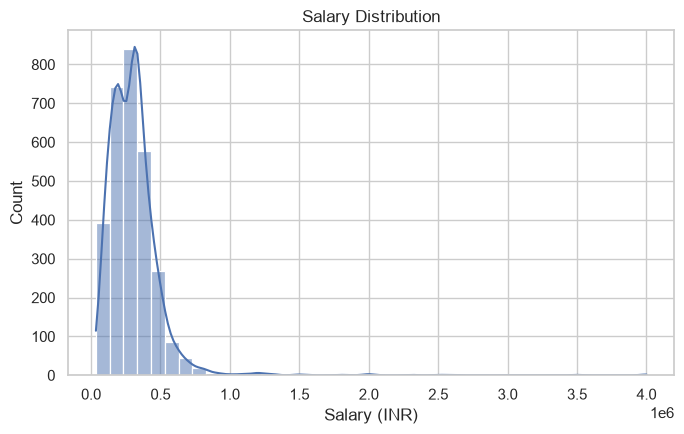

In [4]:
plt.figure(figsize=(7, 4.5))
sns.histplot(df["Salary"], bins=40, kde=True)
plt.xlabel("Salary (INR)"); plt.title("Salary Distribution")
plt.tight_layout(); plt.show()

**Interpretation.** Salary is heavily **right-skewed** with a long tail up to
4,000,000 INR. A handful of extreme values will dominate the squared-error loss
and pull a linear fit off the bulk of graduates, so we cap the top 1% below.

In [5]:
# Columns to consider. Subject-specific skill scores use -1 for "not attempted".
skill_cols = ["ComputerProgramming", "ElectronicsAndSemicon", "ComputerScience",
              "MechanicalEngg", "ElectricalEngg", "TelecomEngg", "CivilEngg"]
missing_share = (df[skill_cols] == -1).mean().sort_values(ascending=False)
missing_share.to_frame("share_of_-1")

,share_of_-1
CivilEngg,0.991328
ElectricalEngg,0.959306
MechanicalEngg,0.937625
TelecomEngg,0.908606
ComputerScience,0.766511
ElectronicsAndSemicon,0.711474
ComputerProgramming,0.216811


**Interpretation - which columns to drop.** `ElectronicsAndSemicon`,
`ComputerScience`, `MechanicalEngg`, `ElectricalEngg`, `TelecomEngg` and
`CivilEngg` are **-1 (not attempted) for 70–99% of students** - they carry almost
no signal and are dropped. `ComputerProgramming` is attempted by most students, so
we keep it and impute the remaining `-1`s with the median. Identifier columns
(`ID`, `DOB`, `CollegeID`, `CollegeCityID`) are dropped because they are not
predictive.

## 3. Feature engineering, numeric conversion & the curated feature set

We convert `Gender` to numeric, treat `-1` sentinels as missing, cap salary
outliers, and select a **curated set of 12 interpretable numeric features** for the
deployed model. (The full 34-column frame above is what the interpretation is
based on; the deployed API uses this clean subset so the mobile form stays usable.)

In [6]:
FEATURES = ["CollegeTier", "collegeGPA", "English", "Logical", "Quant", "Domain",
            "ComputerProgramming", "conscientiousness", "agreeableness",
            "extraversion", "nueroticism", "openess_to_experience"]
TARGET = "Salary"

data = df.copy()
data["Gender"] = (data["Gender"] == "m").astype(int)  # numeric conversion example

# -1 sentinels -> median imputation
for col in ["ComputerProgramming", "Domain"]:
    data[col] = data[col].replace(-1, np.nan)
cp_median = data["ComputerProgramming"].median()
dom_median = data["Domain"].median()
data["ComputerProgramming"] = data["ComputerProgramming"].fillna(cp_median)
data["Domain"] = data["Domain"].fillna(dom_median)

# Cap top-1% salary outliers
cap = data[TARGET].quantile(0.99)
data = data[data[TARGET] <= cap].copy()
print("Rows after cleaning:", data.shape[0], "| salary cap:", int(cap))

X = data[FEATURES].astype(float)
y = data[TARGET].astype(float)

Rows after cleaning: 2968 | salary cap: 880600


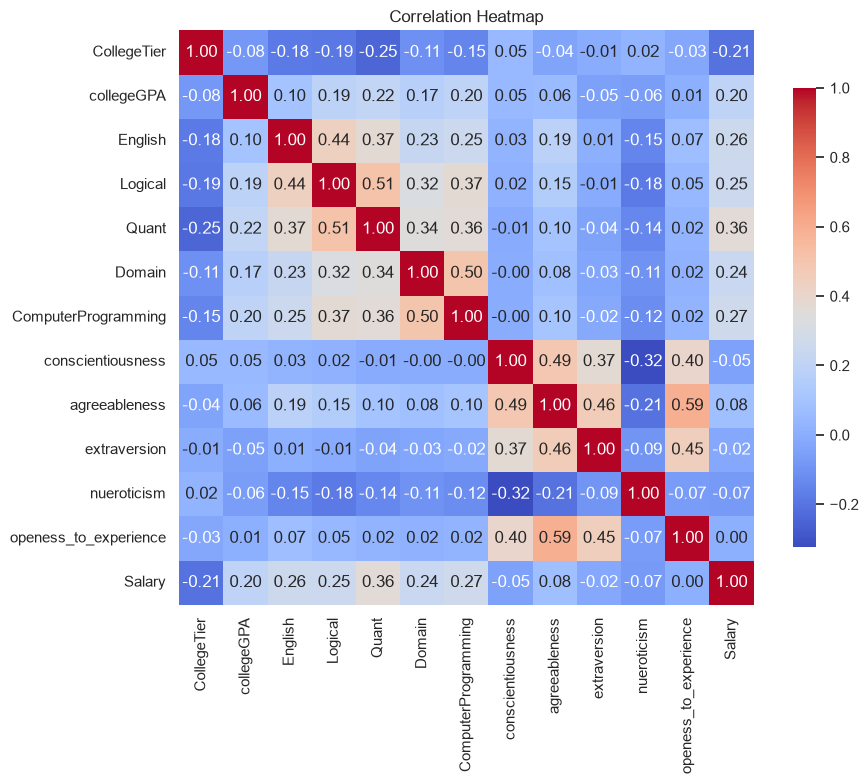

In [7]:
plt.figure(figsize=(10, 8))
corr = data[FEATURES + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap"); plt.tight_layout(); plt.show()

**Interpretation - feature weight.** The aptitude scores **Quant, English and
Logical** and **collegeGPA** show the strongest positive correlation with salary,
while **CollegeTier** is negatively correlated (tier 1 is the better college, so a
lower number means higher pay). Personality traits correlate only weakly. This
tells us the aptitude/academic block carries most of the predictive weight.

Strongest linear predictor: Quant


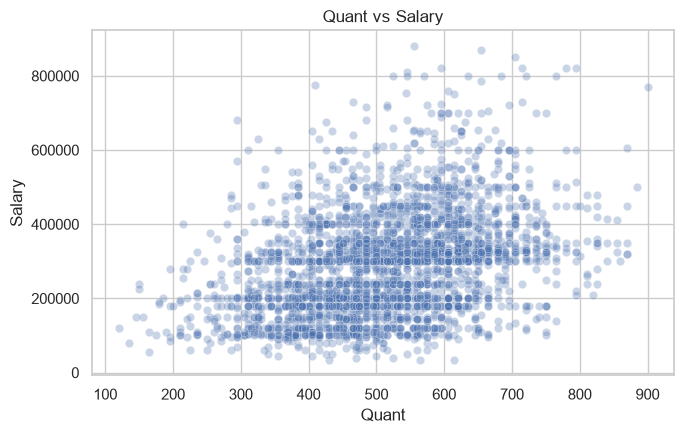

In [8]:
top_feat = corr[TARGET].drop(TARGET).abs().idxmax()
print("Strongest linear predictor:", top_feat)
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x=data[top_feat], y=y, alpha=0.3)
plt.xlabel(top_feat); plt.ylabel("Salary"); plt.title(f"{top_feat} vs Salary")
plt.tight_layout(); plt.show()

## 4. Train/test split and standardization

Features are standardized with `StandardScaler` (fit on the **train** set only) so
that gradient descent converges well and all features are on a comparable scale.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", X_train_s.shape, "Test:", X_test_s.shape)

Train: (2374, 12) Test: (594, 12)


## 5. Model comparison - 4 algorithms

We compare stochastic gradient-descent linear regression against three other
implementations: closed-form linear regression, a decision tree, and a random
forest. The **loss metric is Mean Squared Error (MSE)**; we also report RMSE (in
INR, interpretable) and R².

In [10]:
results = {}

def evaluate(name, model):
    pred_te, pred_tr = model.predict(X_test_s), model.predict(X_train_s)
    results[name] = {
        "model": model,
        "test_mse": mean_squared_error(y_test, pred_te),
        "test_rmse": mean_squared_error(y_test, pred_te) ** 0.5,
        "test_r2": r2_score(y_test, pred_te),
        "train_rmse": mean_squared_error(y_train, pred_tr) ** 0.5,
    }

# 1) Stochastic Gradient Descent linear regression (the required one)
sgd = SGDRegressor(loss="squared_error", penalty="l2", alpha=1e-4,
                   learning_rate="invscaling", eta0=0.01, max_iter=2000,
                   random_state=RANDOM_STATE)
sgd.fit(X_train_s, y_train); evaluate("SGD (Gradient Descent)", sgd)

# 2) Closed-form Linear Regression (OLS)
lr = LinearRegression().fit(X_train_s, y_train); evaluate("Linear Regression (OLS)", lr)

# 3) Decision Tree
dt = DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE)
dt.fit(X_train_s, y_train); evaluate("Decision Tree", dt)

# 4) Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10,
                           random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_s, y_train); evaluate("Random Forest", rf)

summary = pd.DataFrame({k: {"Test RMSE": v["test_rmse"], "Test MSE": v["test_mse"],
                            "Test R2": v["test_r2"]} for k, v in results.items()}).T
summary.sort_values("Test RMSE")

,Test RMSE,Test MSE,Test R2
Linear Regression (OLS),129533.964388,1.677905e+10,0.200699
Random Forest,129592.479367,1.679421e+10,0.199976
SGD (Gradient Descent),129733.708325,1.683084e+10,0.198232
Decision Tree,135078.889985,1.824631e+10,0.130803


In [11]:
best_name = min(results, key=lambda k: results[k]["test_rmse"])
print("Best model (lowest test RMSE / MSE):", best_name)

Best model (lowest test RMSE / MSE): Linear Regression (OLS)


**Criterion for "best".** We select the model with the **lowest test MSE/RMSE**
(the loss metric) - i.e. the smallest average squared prediction error on unseen
data. The linear models and the random forest are near-tied; the closed-form
**Linear Regression** wins narrowly, and SGD converges to essentially the same
solution, confirming the relationship is close to linear.

## 6. Loss curve - train vs test (SGD via `partial_fit`)

We train the SGD model one epoch at a time and record MSE on the train and test
sets after each epoch.

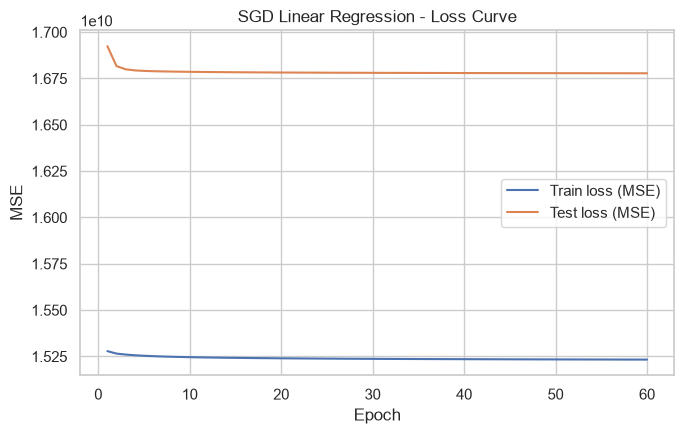

In [12]:
sgd_lc = SGDRegressor(loss="squared_error", penalty="l2", alpha=1e-4,
                      learning_rate="invscaling", eta0=0.01,
                      random_state=RANDOM_STATE)
n_epochs = 60
train_loss, test_loss = [], []
for _ in range(n_epochs):
    sgd_lc.partial_fit(X_train_s, y_train)
    train_loss.append(mean_squared_error(y_train, sgd_lc.predict(X_train_s)))
    test_loss.append(mean_squared_error(y_test, sgd_lc.predict(X_test_s)))

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, n_epochs + 1), train_loss, label="Train loss (MSE)")
plt.plot(range(1, n_epochs + 1), test_loss, label="Test loss (MSE)")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("SGD Linear Regression - Loss Curve")
plt.legend(); plt.tight_layout(); plt.show()

**Interpretation.** Both curves fall quickly and then **plateau together** with a
small gap - the model is **not overfitting** (train and test loss stay close). The
plateau height is set by the irreducible noise in salary, which is why adding more
epochs alone will not lower the loss much.

## 7. Scatter plots - before vs after fitting the linear line

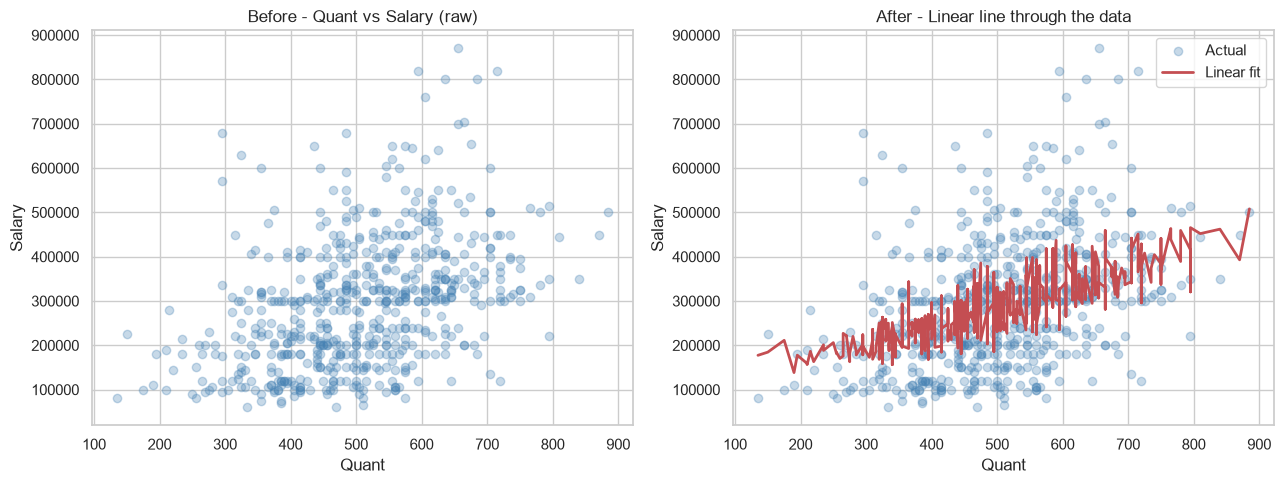

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# BEFORE: raw data, no fitted line
axes[0].scatter(X_test[top_feat], y_test, alpha=0.3, color="steelblue")
axes[0].set_title(f"Before - {top_feat} vs Salary (raw)")
axes[0].set_xlabel(top_feat); axes[0].set_ylabel("Salary")

# AFTER: linear fit line through the data
xt = X_test[top_feat].values
order = np.argsort(xt)
lr_pred = lr.predict(X_test_s)
axes[1].scatter(xt, y_test, alpha=0.3, color="steelblue", label="Actual")
axes[1].plot(xt[order], lr_pred[order], "r-", lw=2, label="Linear fit")
axes[1].set_title(f"After - Linear line through the data")
axes[1].set_xlabel(top_feat); axes[1].set_ylabel("Salary"); axes[1].legend()
plt.tight_layout(); plt.show()

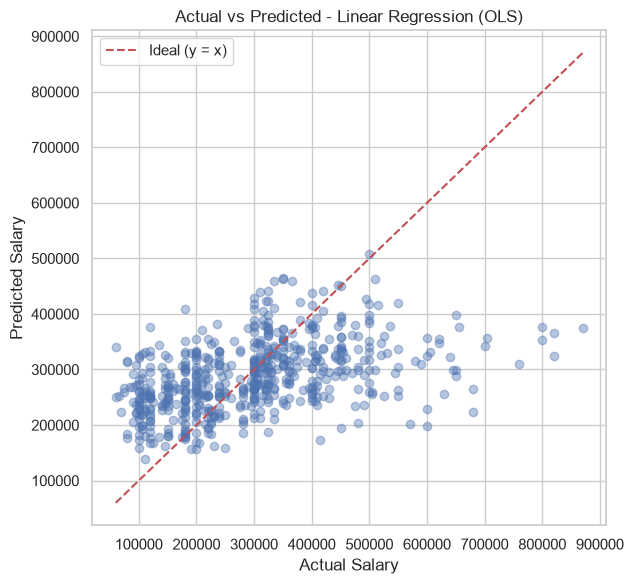

In [14]:
# Actual vs predicted for the best model (ideal = points on the red line)
best_model = results[best_name]["model"]
y_pred_best = best_model.predict(X_test_s)
plt.figure(figsize=(6.5, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="Ideal (y = x)")
plt.xlabel("Actual Salary"); plt.ylabel("Predicted Salary")
plt.title(f"Actual vs Predicted - {best_name}"); plt.legend()
plt.tight_layout(); plt.show()

## 8. Save the best model and the scaler

In [15]:
joblib.dump(best_model, MODELS / "best_model.pkl")
joblib.dump(scaler, MODELS / "scaler.pkl")
metadata = {"features": FEATURES, "best_model": best_name,
            "cp_median": float(cp_median), "domain_median": float(dom_median)}
joblib.dump(metadata, MODELS / "metadata.pkl")
print("Saved best model:", best_name)
print("Artifacts:", [p.name for p in MODELS.iterdir()])

Saved best model: Linear Regression (OLS)
Artifacts: ['scaler.pkl', 'best_model.pkl', 'metadata.pkl']


## 9. Predict a single row from the test set

This is the exact transformation the API reuses: take one row of inputs, scale
with the saved scaler, and predict with the saved model.

In [16]:
one_row = X_test.iloc[[0]]
one_scaled = scaler.transform(one_row)
pred = float(best_model.predict(one_scaled)[0])
print("Input features:")
print(one_row.T)
print(f"\nPredicted salary: {pred:,.0f} INR")
print(f"Actual salary:    {y_test.iloc[0]:,.0f} INR")

Input features:
                            2424
CollegeTier              2.00000
collegeGPA              78.50000
English                515.00000
Logical                505.00000
Quant                  454.00000
Domain                   0.70409
ComputerProgramming    465.00000
conscientiousness       -0.10820
agreeableness            0.96880
extraversion             0.81710
nueroticism             -0.87780
openess_to_experience    0.34440

Predicted salary: 298,723 INR
Actual salary:    480,000 INR
